# Entity linking (LLM-only parsing)

> Copy of [`entity_linking.ipynb`](entity_linking.ipynb) where every address is parsed by the
> LLM alone, instead of regex parsing with an LLM fallback. Addresses that notebook already parsed with the
> LLM fallback reuse its cached parses, so only the ones it regex parsed are sent to the LLM (requires the
> vLLM server to be running when they aren't cached yet).

> **Notebook convention:** keep this notebook limited to function calls and variable
> definitions (configuration, experiment parameters, calls whose results are displayed).
> Every function, class and significant chunk of logic belongs in the support script
> [`entity_linking_notebook_utils.py`](entity_linking_notebook_utils.py), taking its
> dependencies as explicit arguments rather than reading notebook globals.
> Please follow this practice when editing the notebook: add new helpers to the
> support script and only call them from here. Jupyter magics (`%sql`, `%load_ext`, ...)
> are the exception, since they must stay in the notebook.
>
> The pipeline components (camp matcher, GeoDB searcher, disambiguator) are built with
> the `build_*` functions of [`modules/entity_linking.py`](modules/entity_linking.py), so
> that production runs with the same parameters evaluated here: tune them there, not here.
>
> `%autoreload` is enabled below, so edits to the support script and to
> `modules/entity_linking.py` are picked up without restarting the kernel.

## Parsing

When running the notebook for the first time, the LLM model must be hosted in a compatible vllm server:
`uv run vllm serve "Qwen/Qwen3.5-9B" -dp 2`

In [1]:
%load_ext autoreload
%autoreload 2
import entity_linking_notebook_utils as utils
utils.setup_logging()
import modules.entity_linking as entity_linking



In [2]:
from pathlib import Path
import pandas as pd

utils.cleanup_previous_run(globals()) # Allow script rerunning

%load_ext sql
SEARCH_INDEX_DIR = ".geo_db_search_index"
geo_db_searcher = entity_linking.build_geo_db_searcher(f"{SEARCH_INDEX_DIR}/tantivy_index")
conn = geo_db_searcher.connection
%config SqlMagic.displaylimit = None
%sql conn --alias duckdb

camp_matcher = entity_linking.build_camp_matcher()

disambiguator = entity_linking.build_disambiguator()

NUM_WORKERS = utils.default_num_workers()
linking_pool = entity_linking.LinkingPool(camp_matcher, geo_db_searcher, disambiguator, NUM_WORKERS)

OVERWRITE_CACHE = False

The 'toml' package isn't installed. To load settings from pyproject.toml or ~/.jupysql/config, install with: pip install toml

2026-10-07 11:12:58.126 INFO     entity_linking entity_linking.py:1038 Initializing GeoDB searcher...
2026-10-07 11:12:58.127 INFO     entity_linking.TantivySearchIndex geo_db_search.py:1102 Initialized TantivySearchIndex object with 384 read threads
2026-10-07 11:12:58.128 INFO     entity_linking.TantivySearchIndex geo_db_search.py:1115 Opening tantivy index at .geo_db_search_index/tantivy_index (already exists: True, read threads: 384, write threads: 8)
2026-10-07 11:12:58.132 INFO     entity_linking.GeoDBSearch geo_db_search.py:1812 Initializing with search cache db :memory:, geo db geo.duckdb, index tantivy (distance threshold 2, prune score threshold 0.20, settle score threshold 0.90, topk 50, priority countries ['DE', 'US', 'IL', 'PL', 'FR', 'RO', 'CZ', 'HU', 'RU'])
2026-10-07 11:12:58.187 INFO     entity_linking.TantivySearchIndex geo_db_search.py:1147 Index already exists at .geo_db_search_index/tantivy_index; skipping population
2026-10-07 11:12:58.189 INFO     entity_linking.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

displaylimit: Value None will be treated as 0 (no limit)

2026-10-07 11:13:02.013 INFO     entity_linking entity_linking.py:1027 Loading camp/ghetto reference matcher...
2026-10-07 11:13:02.014 INFO     entity_linking.CampReferenceMatcher camp_search.py:90 Loading camp/ghetto reference list from reference_data/wikidata_camps_and_ghettos.csv
2026-10-07 11:13:02.954 WARNING  entity_linking.CampReferenceMatcher camp_search.py:110 Ignoring invalid geonames id 11862441 for http://www.wikidata.org/entity/Q662563
2026-10-07 11:13:07.185 INFO     entity_linking.CampReferenceMatcher camp_search.py:162 Indexed 20968 keys for 1780 places (50 places with a resolved geonames id, 66 ambiguous keys dropped)
2026-10-07 11:13:07.186 INFO     entity_linking.Disambiguator geo_disambiguation.py:370 Initialized with significance thresholds defaultdict(<function _default_significance_threshold at 0x7f477fd25bc0>, {'fuzzy_similarity_score': 0, 'population_order_of_magnitude': 1, 'weighted_score': 0.05, 'child_parent_likelihood': 0.05, 'entity_types_matching_preferr

In [3]:
utils.print_storage_sizes(SEARCH_INDEX_DIR)

DB Size: 5.60 GB
Search index Size: 0.00 GB


In [4]:
%%sql
SELECT COUNT(*) AS number_of_cities FROM geo_db.geographical_entities WHERE classification LIKE 'P%';


Running query in 'duckdb'

number_of_cities
5207715


5 195 947 populated places in geonames against [2 887 930](https://query.wikidata.org/#SELECT%20%28COUNT%28DISTINCT%20%3Fid%29%20AS%20%3Fcount%29%20WHERE%20%7B%0A%20%20%3Fid%20wdt%3AP31%20%2F%20wdt%3AP279%2a%20wd%3AQ123964505.%0A%7D) on wikidata

However there are [709 681](https://query.wikidata.org/#SELECT%20%28COUNT%28DISTINCT%20%3Fid%29%20AS%20%3Fcount%29%20WHERE%20%7B%0A%20%20%3Fid%20wdt%3AP31%20%2F%20wdt%3AP279%2a%20wd%3AQ123964505.%0A%20%20%3Fid%20wdt%3AP1566%20%3FsomeGeonamesId%0A%7D) wikidata populated places that don't link to a geoname.

Among which [13 554](https://query.wikidata.org/#SELECT%20%28COUNT%28DISTINCT%20%3Fid%29%20AS%20%3Fcount%29%20WHERE%20%7B%0A%20%20%3Fid%20wdt%3AP31%20%2F%20wdt%3AP279%2a%20wd%3AQ253019.%0A%20%20%3Fid%20wdt%3AP1566%20%3FsomeGeonamesId%0A%7D) are ["Ortsteil"](https://www.wikidata.org/wiki/Q253019) including [Sudberg](https://www.wikidata.org/wiki/Q2362997) in Wuppertal, which is present in bzk open but not [geonames](https://www.geonames.org/2805753/wuppertal.html) neither gnd.

In [5]:
# Only "FullAddress"/"field"/"card_id"/"address_id" (the raw input text and its
# identifiers) are used as pipeline input below; "iri" is kept as the
# ground-truth label to evaluate predictions against, never as parsing input.
bzkopen_gt = utils.load_ground_truth("open_data/bzkopen_linking_groundtruth.jsonl")
bzkopen_merged = bzkopen_gt
print(f"Total addresses: {len(bzkopen_merged)}")
ESTIMATED_TOTAL_ADDRESSES = 4_228_682 # from compare.ipynb

Total addresses: 1090


In [6]:
# Addresses the regex + LLM run (entity_linking.ipynb) already parsed with the LLM
# fallback reuse that run's parses: only the ones it regex parsed are parsed here.
BASELINE_PARSED_ADDRESSES_CACHE_PATH = Path("experiments_data/entity_linking/parsed_addresses.jsonl")
PARSED_ADDRESSES_CACHE_PATH = Path("experiments_data/entity_linking/parsed_addresses_llm_only.jsonl")
parsed_addresses = await utils.load_or_build_llm_only_parsed_addresses(
    bzkopen_merged, PARSED_ADDRESSES_CACHE_PATH, BASELINE_PARSED_ADDRESSES_CACHE_PATH, overwrite=OVERWRITE_CACHE,
)
parsed_addresses

Running regex parsing on 1090 addresses...
606/1090 addresses need the LLM fallback (regex left them un/partially parsed).
Retrieving cached parsed addresses from experiments_data/entity_linking/parsed_addresses.jsonl...
Reusing the regex + LLM run parses of 606/1090 addresses it did not regex parse.
Retrieving cached parsed addresses from experiments_data/entity_linking/parsed_addresses_llm_only.jsonl...


,abp.City.text,abp.llm_metadata.fullConversation,abp.llm_metadata.example_metadata,abp.status,abp.llm_parser,abp.raw,card_id,address_id,field,prefix,...,vca.Country.text,vdp.Country.text,vdp.Neighborhood.text,abp.Other,vca.State,aca.State,abp.StreetName.text,abp.HouseNumber.text,aca.Other,vca.Other
0,Ruskowa,"[{""role"": ""user"", ""content"": ""# Role\n\nYou ar...","[{'corpus_id': 0, 'score': 1.0, 'address': 'Ru...",llm_parsed,Qwen/Qwen3.5-9B,Ruskowa,train_0,0,ApplicantBirthPlace,abp,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,train_0,1,ApplicantCurrentAddress,aca,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Drohobycz,"[{""role"": ""user"", ""content"": ""# Role\n\nYou ar...","[{'corpus_id': 2, 'score': 1.0, 'address': 'Dr...",llm_parsed,Qwen/Qwen3.5-9B,Drohobycz,train_1,2,ApplicantBirthPlace,abp,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,train_1,3,ApplicantCurrentAddress,aca,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,train_2,4,VictimBirthPlace,vbp,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1085,Berlin,"[{""role"": ""user"", ""content"": ""# Role\n\nYou ar...","[{'corpus_id': 713, 'score': 1.0000001192, 'ad...",llm_parsed,Qwen/Qwen3.5-9B,Berlin,test_76,1086,ApplicantBirthPlace,abp,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1086,NaN,NaN,NaN,NaN,NaN,NaN,test_76,1087,ApplicantCurrentAddress,aca,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1087,Delmenhorst,"[{""role"": ""user"", ""content"": ""# Role\n\nYou ar...","[{'corpus_id': 0, 'score': 1.0, 'pattern_score...",llm_parsed,Qwen/Qwen3.5-9B,Delmenhorst,test_77,1088,ApplicantBirthPlace,abp,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1088,NaN,NaN,NaN,NaN,NaN,NaN,test_77,1089,ApplicantCurrentAddress,aca,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
%load_ext line_profiler
parsed_rows = parsed_addresses.to_dict(orient="records")
outcomes = utils.run_pipeline(
    parsed_rows, linking_pool,
    estimated_total_addresses=ESTIMATED_TOTAL_ADDRESSES,
)

Running full entity linking pipeline on regex+LLM parsed addresses (using 8 worker processes)...


  0%|          | 0/1090 [00:00<?, ?it/s]

2026-10-07 11:13:09.897 INFO     entity_linking.TantivySearchIndex geo_db_search.py:1115 Opening tantivy index at .geo_db_search_index/tantivy_index (already exists: True, read threads: 1, write threads: 8)
2026-10-07 11:13:11.010 INFO     entity_linking.TantivySearchIndex geo_db_search.py:1115 Opening tantivy index at .geo_db_search_index/tantivy_index (already exists: True, read threads: 1, write threads: 8)
2026-10-07 11:13:12.182 INFO     entity_linking.TantivySearchIndex geo_db_search.py:1115 Opening tantivy index at .geo_db_search_index/tantivy_index (already exists: True, read threads: 1, write threads: 8)
2026-10-07 11:13:13.354 INFO     entity_linking.TantivySearchIndex geo_db_search.py:1115 Opening tantivy index at .geo_db_search_index/tantivy_index (already exists: True, read threads: 1, write threads: 8)
2026-10-07 11:13:14.536 INFO     entity_linking.TantivySearchIndex geo_db_search.py:1115 Opening tantivy index at .geo_db_search_index/tantivy_index (already exists: True, 

In [8]:
utils.print_slowest_addresses(outcomes, parsed_rows)

    221 Miami, Florida, 231 N.W. 3rd. Str. (0:00:05)
    88 Vicente Lopes, Prov. Buenos-Aires/Argent. 25, de Mayo 102 (0:00:04)
    1083 Buenos Aires/Argent. Ciudad de la Paz 1482 7 piso (0:00:03)
    998 San Mateo, Calif. (0:00:03)
    1081 Olivos/Prov. Buenos-Aires Sarmiento 2147 Argentinien (0:00:03)
    60 San Francisco, Calif., USA 3065 Clay Street (0:00:02)
    534 Aschendorf/Ems, Altenkamp (0:00:02)
    127 Diablo, California USA. (0:00:02)
    996 831 Alameda, San Mateo, Calif. (0:00:02)
    883 3/51 Roscoe Street, Bondi Sydney/Austr. (0:00:02)
    683 La Lucila. San Lorenzo 734 ( Prov.B' Aires) Argenti- nien (0:00:02)
    445 Hamburg Berne, Farenland 5 (0:00:02)
    220 Roedingen Bez. Aachen (0:00:02)
    820 Hohenrode   Haus-Nr. 29 (0:00:02)
    183 Caracas Urb. Los Caobos Avda Bogota Qta. Milagros (0:00:02)
    151 Jerusalem Baka 13/16 (0:00:02)
    332 Muniz, (Provinz Buenos Aires), calle Munoz 1084 Argentinien (0:00:02)
    785 Haspe-Hagen (0:00:02)
    880 Hagen-Haspe (0:

In [9]:
disambiguated_addresses = utils.build_disambiguated_addresses_df(bzkopen_merged, outcomes)
disambiguated_addresses

,card_id,address_id,bzk_field_name,full_address,raw_address_part,matched_name,country,iri,entity_type,search_status,child_parent_likelihood
0,train_0,0,ApplicantBirthPlace,Ruskowa,Ruskowa,Ruszkowa,Poland,https://sws.geonames.org/759955,City,GEO_DB_PHONETIC_MATCH,1.000000
1,train_0,1,ApplicantCurrentAddress,"170 Clymer Street, Brooklyn, N.Y. USA",Brooklyn,Brooklyn,United States,https://sws.geonames.org/5110302,Neighborhood,GEO_DB_EXACT_MATCH,1.000000
2,train_1,2,ApplicantBirthPlace,Drohobycz,Drohobycz,Drohobycz,Ukraine,https://sws.geonames.org/709611,City,GEO_DB_EXACT_MATCH,1.000000
3,train_1,3,ApplicantCurrentAddress,"London N.W.3/England, 109 Green Hill",London,London,United Kingdom,https://sws.geonames.org/2643743,City,GEO_DB_EXACT_MATCH,1.000000
4,train_2,4,VictimBirthPlace,Dresden,Dresden,Dresden,Germany,https://sws.geonames.org/2935022,City,GEO_DB_EXACT_MATCH,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
1048,test_76,1086,ApplicantBirthPlace,Berlin,Berlin,Berlin,Germany,https://sws.geonames.org/2950159,City,GEO_DB_EXACT_MATCH,1.000000
1049,test_76,1087,ApplicantCurrentAddress,"Tiberias/Israel, Box 90",Tiberias,Tiberias,Israel,https://sws.geonames.org/293322,City,GEO_DB_EXACT_MATCH,1.000000
1050,test_77,1088,ApplicantBirthPlace,Delmenhorst,Delmenhorst,Delmenhorst,Germany,https://sws.geonames.org/2938323,City,GEO_DB_EXACT_MATCH,1.000000
1051,test_77,1089,ApplicantCurrentAddress,"East-Ormund - Melbourne - Vic./Australia, 53 L...",Melbourne,Melbourne,Australia,https://sws.geonames.org/2158177,City,GEO_DB_EXACT_MATCH,0.666667


In [10]:
recovered_missed_words = utils.build_recovered_missed_words_df(parsed_rows, outcomes)
print(f"Addresses with recovered missed words: {len(recovered_missed_words)}")
recovered_missed_words

Addresses with recovered missed words: 201


,address_id,parse_status,bzk_field_name,raw_address,parsed_entities,recovered_missed_words,linked_missed_words,iri,entity_type
0,3,llm_parsed,ApplicantCurrentAddress,"London N.W.3/England, 109 Green Hill","{'City': 'London', 'StreetName': 'Green Hill',...",[England],[England],https://sws.geonames.org/2643743,City
1,5,llm_parsed,VictimCurrentAddress,"Darmstadt, Hessen, Schloßgartenstr. 47 ptr. 1","{'City': 'Darmstadt', 'StreetName': 'Schloßgar...",[Hessen],[Hessen],https://sws.geonames.org/2938913,City
2,11,llm_parsed,VictimCurrentAddress,"Giwattaim, Sohun. Rosenstein Nr.32","{'City': 'Giwattaim', 'StreetName': 'Rosenstei...",[Sohun.],[],https://sws.geonames.org/294999,City
3,20,llm_parsed,ApplicantCurrentAddress,"350 No. Fuller Ave, Los Angeles 36, Calif. USA","{'Country': 'USA', 'City': 'Los Angeles', 'Str...",[Calif.],[Calif.],https://sws.geonames.org/5368361,City
4,26,llm_parsed,ApplicantBirthPlace,Friedrichsrode/Thüringen,{'City': 'Friedrichsrode'},[Thüringen],[Thüringen],https://sws.geonames.org/2924489,City
...,...,...,...,...,...,...,...,...,...
196,1042,llm_parsed,VictimCurrentAddress,"Rüsselsheim, Wilk.-Röntgen-Str.23, Krs. Groß-G...","{'City': 'Rüsselsheim', 'StreetName': 'Wilk.-R...",[Groß-Gerau],[Groß-Gerau],https://sws.geonames.org/2842884,City
197,1071,llm_parsed,VictimCurrentAddress,"Detroit, 96 <UNK> Michigan US","{'Country': 'US', 'City': 'Detroit', 'Neighbor...",[Michigan],[Michigan],https://sws.geonames.org/4990729,City
198,1072,llm_parsed,ApplicantBirthPlace,Walsdorf b. Bamberg,{'City': 'Walsdorf'},[Bamberg],[],http://www.wikidata.org/entity/Q1719426,Camp
199,1081,llm_parsed,ApplicantCurrentAddress,Olivos/Prov. Buenos-Aires Sarmiento 2147 Argen...,"{'Country': 'Argentinien', 'City': 'Olivos', '...",[Buenos-Aires],[Buenos-Aires],https://sws.geonames.org/3430310,City


In [11]:
pipeline_metrics = utils.evaluate_outcomes(outcomes, bzkopen_gt)
pipeline_metrics

{'tp': 941,
 'fp': 112,
 'fn': 12,
 'tn': 25,
 'total': 1090,
 'precision': 0.8936372269705603,
 'recall': 0.9874081846799581,
 'f1': 0.9381854436689929,
 'accuracy': 0.8862385321100917,
 'granularity_loss_of_0': 940,
 'granularity_loss_of_6': 25,
 'granularity_loss_of_5': 40,
 'granularity_loss_of_4': 36,
 'granularity_loss_of_2': 5,
 'granularity_loss_of_3': 16,
 'granularity_loss_of_1': 3,
 'full_granularity_loss': 105,
 'some_granularity_loss': 20,
 'partial_link_to_Country': 13,
 'partial_link_to_State': 5,
 'partial_link_to_City': 1,
 'partial_link_to_Neighborhood': 1,
 'granularity_score': 0.993291860290811}

Legend:
 - 'Correctly Linked' the final IRI predicted for the address is exactly the same as the ground truth IRI
 - 'Partially Linked' means the final IRI refers to a location that contains the address but is not as
    granular as possible (e.g. the IRI for the country instead of the city)
 - 'Incorrectly Linked' means the final IRI refers to a different unrelated location
 - 'Failed to link' means either no IRI was found for the address or multiple IRIs were found with no way to
    disambiguate between them
 - 'Not a location' means the predicted raw value does not contain any location that can be linked (e.g. Deportation)


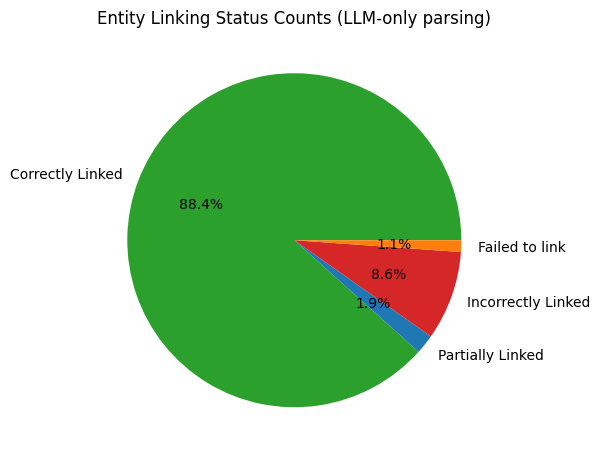

In [12]:
pipeline_pie_chart_coarse = utils.linking_status_counts(outcomes, bzkopen_gt)
utils.print_linking_status_legend()
utils.plot_linking_status_pie(pipeline_pie_chart_coarse, title="Entity Linking Status Counts (LLM-only parsing)")

Classification names (first matching name wins):
 - Country: A.PCL*, A.TERR, A.LTER, A.ZN, A.PRSH
 - State: A.ADM1, A.ADM1H, A.ADMD, A.ADMDH
 - Region: L.RGN*, H.STM*, H.LK*, H.RSV, */Q82794, REGIONAL_TERM
 - District: A.ADM[2-5], A.ADM[2-5]H
 - Neighborhood: P.PPLX, */Q253019, */Q123705
 - City: P.PPL*, */Q486972, */Q262166
 - Camp: linked by the camp/ghetto reference matcher
 - Other: any other classification
 - No classification: the linked entity has no classification


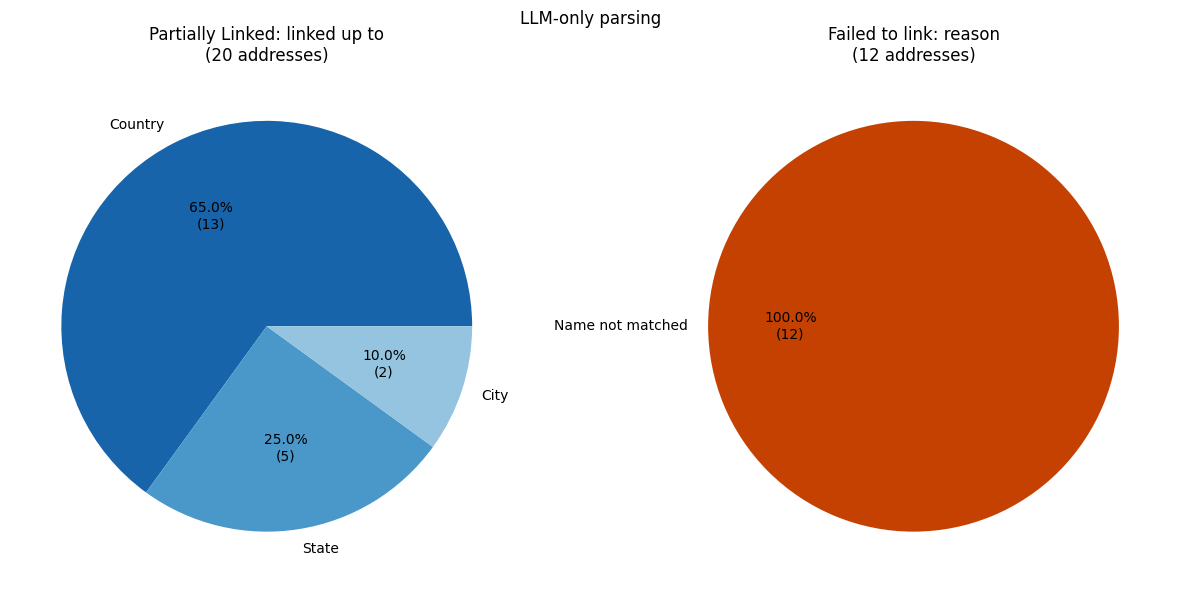

In [13]:
partial_link_counts = utils.partial_link_classification_counts(outcomes, bzkopen_gt, conn)
utils.print_classification_names()
failed_to_link_counts = utils.failed_to_link_reason_counts(outcomes, bzkopen_gt)
utils.plot_partial_and_failed_link_pies(partial_link_counts, failed_to_link_counts, title="LLM-only parsing")

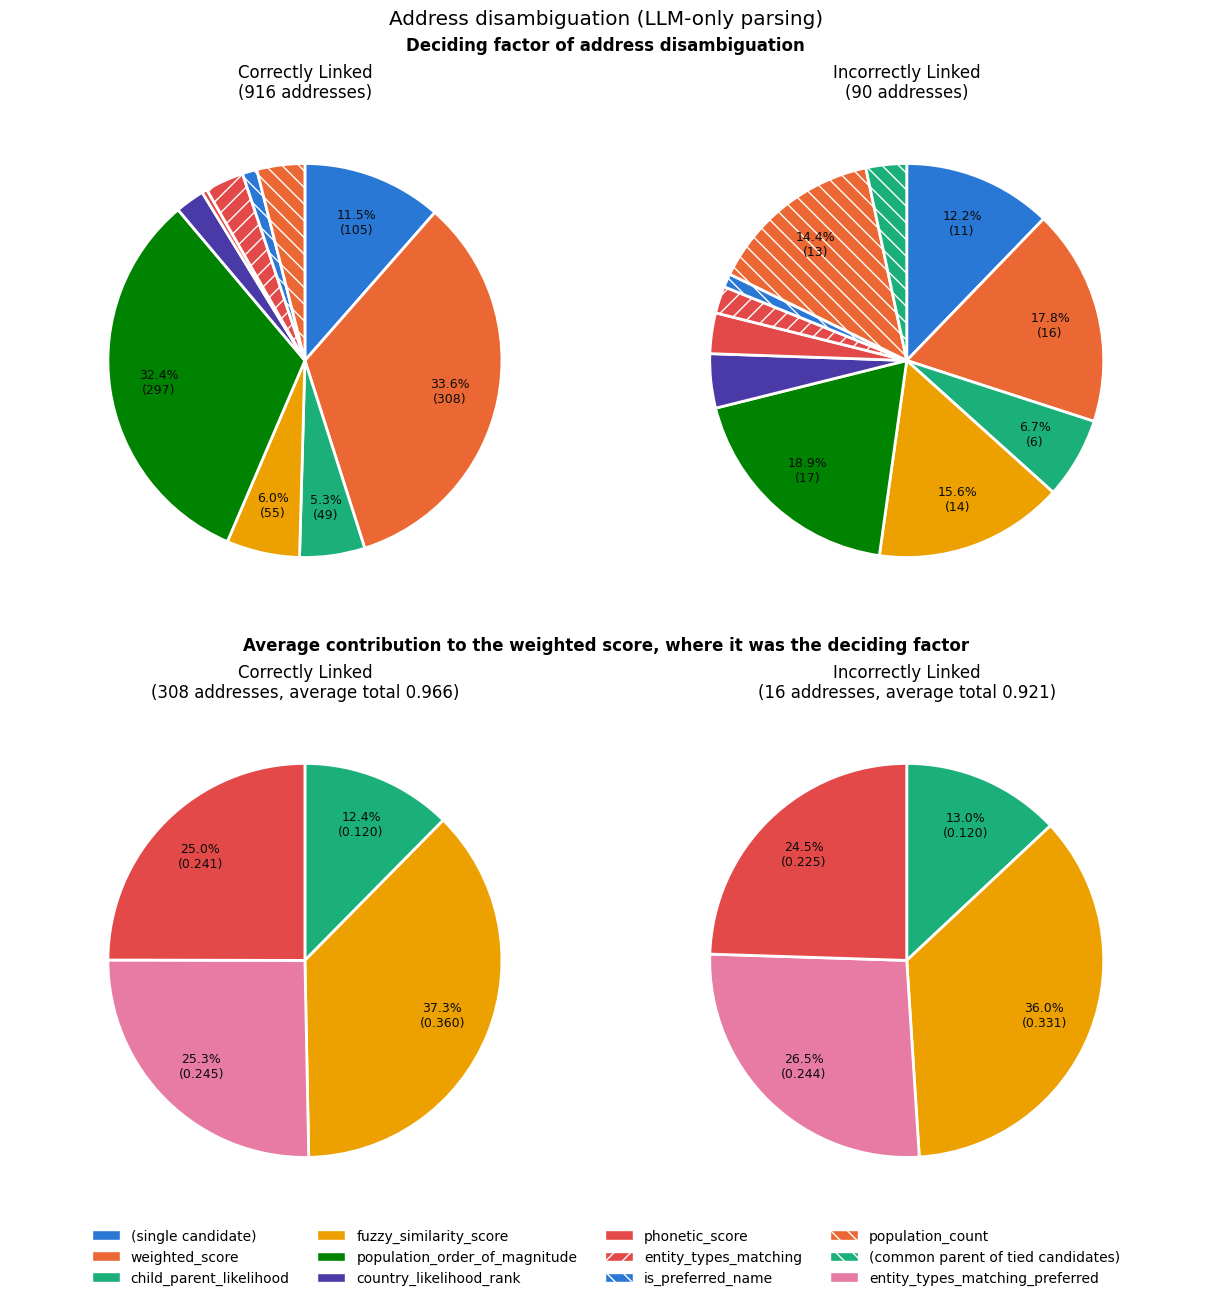

,Correctly Linked,Incorrectly Linked
(single candidate),105,11
weighted_score,308,16
child_parent_likelihood,49,6
fuzzy_similarity_score,55,14
population_order_of_magnitude,297,17
country_likelihood_rank,22,4
phonetic_score,4,3
entity_types_matching,29,2
is_preferred_name,11,1
population_count,36,13


,Correctly Linked,Incorrectly Linked
child_parent_likelihood,0.119700,0.119834
fuzzy_similarity_score,0.360269,0.331259
entity_types_matching_preferred,0.244784,0.244271
phonetic_score,0.241153,0.225498


,deciding_factor,address_id,card_id,bzk_field_name,full_address,true_iri,pred_iri,pred_entity_type,pred_raw_text,pred_matched_name,pred_country
0,(single candidate),86,train_39,ApplicantCurrentAddress,"Ber Schewa Isr., Ruben Halperin Schikun Amidar...",https://sws.geonames.org/11551151,https://sws.geonames.org/295530,City,Ber Schewa,Beer Scheva,Israel
1,(single candidate),153,train_69,ApplicantCurrentAddress,Tel-Aviv Kir. Schalom 42,https://sws.geonames.org/293827,https://sws.geonames.org/293783,Neighborhood,Kir. Schalom,‘Ir Shalom,Israel
2,(single candidate),165,train_73,VictimCurrentAddress,"Szillau Csomio, Ungarn",https://sws.geonames.org/667101,https://sws.geonames.org/719819,Country,Ungarn,Ungarn,Hungary
3,(single candidate),255,train_110,VictimCurrentAddress,Palestina Chadar Josef 146,https://sws.geonames.org/294950,https://sws.geonames.org/6254930,Country,Palestina,Palästina,Palestinian Territory
4,(single candidate),405,train_178,VictimBirthPlace,Antonienhütte/Krs. Kattowitz,https://sws.geonames.org/3081887,https://sws.geonames.org/2513106,City,Antonienhütte,Onteniente,Spain
...,...,...,...,...,...,...,...,...,...,...,...
85,population_count,1027,test_50,ApplicantCurrentAddress,Berg Ludwigstr. 27,https://sws.geonames.org/2950721,https://sws.geonames.org/2950725,City,Berg,Berg,Germany
86,population_count,1028,test_51,ApplicantBirthPlace,Tiaveco/CSR.,https://sws.geonames.org/690906,https://sws.geonames.org/3077158,City,Tiaveco,Diváky,Czechia
87,(common parent of tied candidates),162,train_72,VictimCurrentAddress,Szellau/Ungarn,https://sws.geonames.org/668248,https://sws.geonames.org/719819,Country,Szellau/Ungarn,Hungary,Hungary
88,(common parent of tied candidates),942,test_9,ApplicantCurrentAddress,"Cedera/Israel Altersheim, Beth Meir von Malben",https://sws.geonames.org/295064,https://sws.geonames.org/2921044,Country,"Cedera/Israel Altersheim, Beth Meir von Malben",Federal Republic of Germany,Germany


In [14]:
deciding_factor_counts = utils.deciding_factor_counts(outcomes, bzkopen_gt)
weighted_score_contributions = utils.weighted_score_contributions(outcomes, bzkopen_gt)
utils.plot_pies_by_link_status({
    "Deciding factor of address disambiguation": deciding_factor_counts,
    "Average contribution to the weighted score, where it was the deciding factor": weighted_score_contributions,
}, title="Address disambiguation (LLM-only parsing)")
display(deciding_factor_counts)
display(weighted_score_contributions)
display(utils.incorrectly_linked_by_deciding_factor(bzkopen_merged, outcomes, bzkopen_gt))

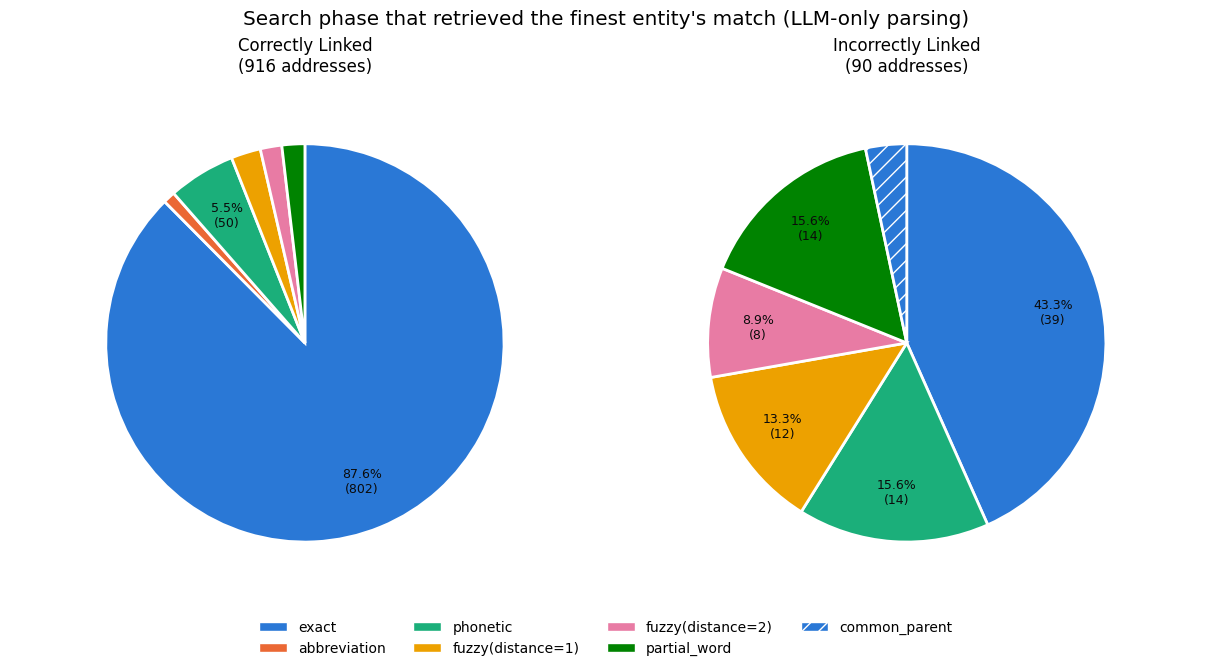

,Correctly Linked,Incorrectly Linked
exact,802,39
abbreviation,9,0
phonetic,50,14
fuzzy(distance=1),22,12
fuzzy(distance=2),16,8
partial_word,17,14
common_parent,0,3


,finest_search_phase,address_id,card_id,bzk_field_name,full_address,true_iri,pred_iri,pred_entity_type,pred_raw_text,pred_matched_name,pred_country
0,exact,17,train_8,VictimBirthPlace,Oberdorf,https://sws.geonames.org/2861077,https://sws.geonames.org/2659399,City,Oberdorf,Oberdorf,Switzerland
1,exact,78,train_35,VictimCurrentAddress,"Weißenburg, Bayern, Südring 10",https://sws.geonames.org/2811909,https://sws.geonames.org/686578,City,Weißenburg,Weißenburg,Romania
2,exact,100,train_46,ApplicantBirthPlace,Tysmienica Po.,https://sws.geonames.org/756450,https://sws.geonames.org/690873,City,Tysmienica,Tyśmienica,Ukraine
3,exact,138,train_63,ApplicantCurrentAddress,"Biberach, Bachgasse 15",https://sws.geonames.org/2949423,https://sws.geonames.org/2949427,City,Biberach,Biberach,Germany
4,exact,150,train_68,ApplicantBirthPlace,Saloniki,https://sws.geonames.org/254133,https://sws.geonames.org/734077,City,Saloniki,Saloníki,Greece
...,...,...,...,...,...,...,...,...,...,...,...
85,partial_word,967,test_20,ApplicantCurrentAddress,Nathania Shikun Vatikim 136,https://sws.geonames.org/294071,https://sws.geonames.org/8142267,Neighborhood,Shikun Vatikim,Shikun Darom,Israel
86,partial_word,1032,test_52,ApplicantBirthPlace,Chorzów-Batory,https://sws.geonames.org/3098056,https://sws.geonames.org/3101619,City,Chorzów,Chorzów,Poland
87,common_parent,162,train_72,VictimCurrentAddress,Szellau/Ungarn,https://sws.geonames.org/668248,https://sws.geonames.org/719819,Country,Szellau/Ungarn,Hungary,Hungary
88,common_parent,942,test_9,ApplicantCurrentAddress,"Cedera/Israel Altersheim, Beth Meir von Malben",https://sws.geonames.org/295064,https://sws.geonames.org/2921044,Country,"Cedera/Israel Altersheim, Beth Meir von Malben",Federal Republic of Germany,Germany


In [15]:
finest_search_phase_counts = utils.finest_search_phase_counts(outcomes, bzkopen_gt)
utils.plot_pies_by_link_status(finest_search_phase_counts, title="Search phase that retrieved the finest entity's match (LLM-only parsing)")
display(finest_search_phase_counts)
display(utils.incorrectly_linked_by_finest_search_phase(bzkopen_merged, outcomes, bzkopen_gt))

In [16]:
RESULTS_DIR = Path("experiments_data/entity_linking/results_llm_only")
indexed_gt = utils.index_by_address_id(bzkopen_gt)
incorrect_or_missing_links_df = utils.build_incorrect_or_missing_links_df(bzkopen_merged, outcomes, parsed_rows, indexed_gt)
links_by_status = utils.split_by_link_status(incorrect_or_missing_links_df)
incorrectly_linked_df = links_by_status.get(utils.LinkStatus.INCORRECTLY_LINKED, pd.DataFrame())
partially_linked_df = links_by_status.get(utils.LinkStatus.PARTIALLY_LINKED, pd.DataFrame())
failed_to_link_df = links_by_status.get(utils.LinkStatus.FAILED_TO_LINK, pd.DataFrame())
utils.save_result_table(incorrectly_linked_df, RESULTS_DIR, "incorrectly_linked")
utils.save_result_table(partially_linked_df, RESULTS_DIR, "partially_linked")
utils.save_result_table(failed_to_link_df, RESULTS_DIR, "failed_to_link")

Saved 92 rows to experiments_data/entity_linking/results_llm_only/incorrectly_linked.jsonl

Saved 92 rows to [experiments_data/entity_linking/results_llm_only/incorrectly_linked.txt](experiments_data/entity_linking/results_llm_only/incorrectly_linked.txt)

Saved 20 rows to experiments_data/entity_linking/results_llm_only/partially_linked.jsonl

Saved 20 rows to [experiments_data/entity_linking/results_llm_only/partially_linked.txt](experiments_data/entity_linking/results_llm_only/partially_linked.txt)

Saved 12 rows to experiments_data/entity_linking/results_llm_only/failed_to_link.jsonl

Saved 12 rows to [experiments_data/entity_linking/results_llm_only/failed_to_link.txt](experiments_data/entity_linking/results_llm_only/failed_to_link.txt)

In [17]:
incorrectly_linked_df

,address_id,card_id,bzk_field_name,full_address,link_status,true_iri,pred_iri,true_entity_type,true_raw_text,pred_raw_text,parsing_status,pred_status,true_tags,pred_tags,pred_entity_type,pred_matched_name,pred_country
0,17,train_8,VictimBirthPlace,Oberdorf,Incorrectly Linked,https://sws.geonames.org/2861077,https://sws.geonames.org/2659399,City,Oberdorf,Oberdorf,llm_parsed,GEO_DB_EXACT_MATCH,[unresolvable_ambiguity],[],City,Oberdorf,Switzerland
1,42,train_17,ApplicantBirthPlace,Teley/Laun,Incorrectly Linked,https://sws.geonames.org/3064291,https://sws.geonames.org/4140642,City,Teley,Teley,llm_parsed,GEO_DB_FUZZY_DISTANCE_1_MATCH,[],[],City,Tenley,United States
2,78,train_35,VictimCurrentAddress,"Weißenburg, Bayern, Südring 10",Incorrectly Linked,https://sws.geonames.org/2811909,https://sws.geonames.org/686578,City,Weißenburg,Weißenburg,llm_parsed,GEO_DB_EXACT_MATCH,[],[],City,Weißenburg,Romania
3,80,train_36,ApplicantCurrentAddress,"Rochest N.Y./USA., 1441 Monroe Avenue",Incorrectly Linked,https://sws.geonames.org/5134086,https://sws.geonames.org/5043471,City,Rochest,Rochest,llm_parsed,GEO_DB_FUZZY_DISTANCE_1_MATCH,[],[],City,Rochert,United States
4,86,train_39,ApplicantCurrentAddress,"Ber Schewa Isr., Ruben Halperin Schikun Amidar...",Incorrectly Linked,https://sws.geonames.org/11551151,https://sws.geonames.org/295530,Neighborhood,Schikun Amidar,Schikun Amidar,llm_parsed,GEO_DB_PHONETIC_MATCH,[],[],City,Beer Scheva,Israel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,1040,test_55,ApplicantCurrentAddress,"Weinsberg b. Heilbronn, Stadtseestr. 25",Incorrectly Linked,https://sws.geonames.org/2812158,https://sws.geonames.org/2907669,City,Weinsberg,Weinsberg,llm_parsed,GEO_DB_FUZZY_MATCH,[],[],Neighborhood,Heilbronn,Germany
88,1069,test_67,VictimDeathPlace,Warschau/Ghetto,Incorrectly Linked,https://sws.geonames.org/11524356,https://sws.geonames.org/756135,Neighborhood,Ghetto,Ghetto,llm_parsed,GEO_DB_EXACT_MATCH,[ghetto],[],City,Warschau,Poland
89,1072,test_69,ApplicantBirthPlace,Walsdorf b. Bamberg,Incorrectly Linked,https://sws.geonames.org/2814478,https://www.wikidata.org/entity/Q1719426,City,Walsdorf,Walsdorf,llm_parsed,CAMP_AND_GHETTO_REFERENCE,[],[concentration_camp],Camp,NaN,NaN
90,1089,test_77,ApplicantCurrentAddress,"East-Ormund - Melbourne - Vic./Australia, 53 L...",Incorrectly Linked,https://sws.geonames.org/2154172,https://sws.geonames.org/2158177,Neighborhood,East-Ormund,East-Ormund,llm_parsed,GEO_DB_EXACT_MATCH,[],[],City,Melbourne,Australia


In [18]:
partially_linked_df

,address_id,card_id,bzk_field_name,full_address,link_status,true_iri,pred_iri,true_entity_type,true_raw_text,pred_raw_text,parsing_status,pred_status,true_tags,pred_tags,pred_entity_type,pred_matched_name,pred_country
0,220,train_95,ApplicantBirthPlace,Roedingen Bez. Aachen,Partially Linked,https://sws.geonames.org/2845923,https://sws.geonames.org/2921044,City,Roedingen,Roedingen,llm_parsed,GEO_DB_EXACT_MATCH,[],[],Country,Federal Republic of Germany,Germany
1,297,train_131,VictimBirthPlace,Siedlice/Polen,Partially Linked,https://sws.geonames.org/3086069,https://sws.geonames.org/798544,City,Siedlice,Siedlice,llm_parsed,GEO_DB_EXACT_MATCH,[unresolvable_ambiguity],[],Country,Republic of Poland,Poland
2,321,train_142,VictimBirthPlace,Petnerhas/Ungarn,Partially Linked,https://sws.geonames.org/716437,https://sws.geonames.org/719819,City,Petnerhas,Petnerhas,llm_parsed,GEO_DB_EXACT_MATCH,[suspected_transliteration],[],Country,Ungarn,Hungary
3,534,train_248,ApplicantCurrentAddress,"Aschendorf/Ems, Altenkamp",Partially Linked,https://sws.geonames.org/2955199,https://sws.geonames.org/2862926,Neighborhood,Altenkamp,Altenkamp,llm_parsed,GEO_DB_EXACT_MATCH,[],[],State,Lower Saxony,Germany
4,675,train_315,ApplicantCurrentAddress,"10, Fulton St., East-St. Kilda, Melbourne, Vic...",Partially Linked,https://sws.geonames.org/7303250,https://sws.geonames.org/2158177,Neighborhood,East-St. Kilda,East-St. Kilda,llm_parsed,GEO_DB_EXACT_MATCH,[],[],City,Melbourne,Australia
5,683,train_318,ApplicantCurrentAddress,La Lucila. San Lorenzo 734 ( Prov.B' Aires) Ar...,Partially Linked,https://sws.geonames.org/3432310,https://sws.geonames.org/3865483,City,La Lucila,La Lucila,llm_parsed,GEO_DB_EXACT_MATCH,[],[],Country,Argentine Republic,Argentina
6,695,train_324,ApplicantBirthPlace,Gorna,Partially Linked,https://sws.geonames.org/3098810,https://sws.geonames.org/798544,City,Gorna,Gorna,llm_parsed,GEO_DB_EXACT_MATCH,[],[],Country,Republic of Poland,Poland
7,819,val_27,VictimBirthPlace,Hohenrode,Partially Linked,https://sws.geonames.org/2901523,https://sws.geonames.org/2862926,City,Hohenrode,Hohenrode,llm_parsed,GEO_DB_EXACT_MATCH,[],[],State,Lower Saxony,Germany
8,820,val_27,VictimCurrentAddress,Hohenrode Haus-Nr. 29,Partially Linked,https://sws.geonames.org/2901523,https://sws.geonames.org/2862926,City,Hohenrode,Hohenrode,llm_parsed,GEO_DB_EXACT_MATCH,[],[],State,Lower Saxony,Germany
9,838,val_37,ApplicantBirthPlace,Richen,Partially Linked,https://sws.geonames.org/2847513,https://sws.geonames.org/2921044,City,Richen,Richen,llm_parsed,GEO_DB_EXACT_MATCH,[],[],Country,Federal Republic of Germany,Germany


In [19]:
failed_to_link_df

,address_id,card_id,bzk_field_name,full_address,link_status,true_iri,pred_iri,true_entity_type,true_raw_text,pred_raw_text,parsing_status,pred_status,true_tags,pred_tags,pred_entity_type,pred_matched_name,pred_country
0,59,train_26,ApplicantBirthPlace,"Thorn, Westpreussen",Failed to link,https://sws.geonames.org/3083271,NaN,District,Thorn,NaN,llm_parsed,EMPTY_PARSING_RESULT,[],[unresolved],NaN,NaN,NaN
1,70,train_31,ApplicantBirthPlace,Thorn/Westpr,Failed to link,https://sws.geonames.org/3083271,NaN,City,Thorn,NaN,llm_parsed,EMPTY_PARSING_RESULT,[],[unresolved],NaN,NaN,NaN
2,159,train_72,ApplicantBirthPlace,Scheumargorosch/Rum.,Failed to link,https://sws.geonames.org/667101,NaN,City,Scheumargorosch,Scheumargorosch,llm_parsed,GEO_DB_NO_CANDIDATES,[suspected_transliteration],[unresolved],NaN,NaN,NaN
3,322,train_142,VictimCurrentAddress,"Beer Jakow. Beth Olim A, 14",Failed to link,https://sws.geonames.org/295525,NaN,City,Beer Jakow.,NaN,llm_parsed,GEO_DB_NO_CANDIDATES,[obvious_transliteration],[unresolved],NaN,NaN,NaN
4,478,train_217,ApplicantBirthPlace,"Dacha Wojczynska, West Ukraine",Failed to link,https://sws.geonames.org/690791,NaN,Country,Ukraine,West Ukraine,llm_parsed,GEO_DB_NO_CANDIDATES,[],[unresolved],NaN,NaN,NaN
5,603,train_281,ApplicantCurrentAddress,Im Moore 35,Failed to link,https://sws.geonames.org/2910831,NaN,City,NaN,NaN,llm_parsed,GEO_DB_NO_CANDIDATES,[],[unresolved],NaN,NaN,NaN
6,825,val_30,VictimBirthPlace,Madiorban-Hedersch/Ung.,Failed to link,https://sws.geonames.org/717943,NaN,Country,Ung.,Ung.,llm_parsed,GEO_DB_NO_CANDIDATES,[suspected_transliteration],[unresolved],NaN,NaN,NaN
7,926,test_2,VictimBirthPlace,Neybator,Failed to link,https://sws.geonames.org/716948,NaN,City,Neybator,Neybator,llm_parsed,GEO_DB_NO_CANDIDATES,[suspected_transliteration],[unresolved],NaN,NaN,NaN
8,946,test_11,ApplicantCurrentAddress,Tel Aviv Schech Schapira Re<UNK> Schiwat Zion 18,Failed to link,https://sws.geonames.org/293397,NaN,City,Tel Aviv,NaN,llm_parsed,GEO_DB_NO_CANDIDATES,[],[unresolved],NaN,NaN,NaN
9,954,test_14,VictimCurrentAddress,London N.W. 6 70 Compayne Gardens,Failed to link,https://sws.geonames.org/2643743,NaN,City,London,NaN,llm_parsed,GEO_DB_NO_CANDIDATES,[],[unresolved],NaN,NaN,NaN


## Differences with the regex + LLM results

Compares the results tables saved above with those of [`entity_linking.ipynb`](entity_linking.ipynb)
(regex parsing with LLM fallback), listing the addresses whose link status or predicted iri changed, with the parse fields
(entity texts and parsing-time `{EntityType}_iri` pre-links, as the pipeline reads them) that differ between both runs.
Addresses absent from a run's tables were correctly linked or are not a location.

✅ Correctly linked · ⚠️ Partially linked · ❌ Incorrectly linked / Failed to link · ❔ Not a location

In [20]:
BASELINE_RESULTS_DIR = Path("experiments_data/entity_linking/results")
DIFF_LABELS = ("regex + LLM", "LLM only")
display(utils.link_status_transitions(BASELINE_RESULTS_DIR, RESULTS_DIR, indexed_gt, labels=DIFF_LABELS))
results_diff = utils.diff_link_results(BASELINE_RESULTS_DIR, RESULTS_DIR, indexed_gt, labels=DIFF_LABELS)
results_diff = utils.add_changed_parse_fields(
    results_diff, utils.load_parsed_addresses(BASELINE_PARSED_ADDRESSES_CACHE_PATH), parsed_addresses, labels=DIFF_LABELS,
)
results_diff

LLM only,✅ Correctly Linked,⚠️ Partially Linked,❌ Incorrectly Linked,❌ Failed to link,❔ Not a location
regex + LLM,,,,,
✅ Correctly Linked,939,1,3,2,0
⚠️ Partially Linked,0,19,0,1,0
❌ Incorrectly Linked,2,0,89,1,0
❌ Failed to link,0,0,0,8,0
❔ Not a location,0,0,0,0,25


,address_id,full_address,changed parse fields (regex + LLM),changed parse fields (LLM only),link_status (regex + LLM),link_status (LLM only),true_iri,pred_iri (regex + LLM),pred_iri (LLM only)
0,534,"Aschendorf/Ems, Altenkamp","{'City': 'Aschendorf/Ems', 'Neighborhood': Non...","{'City': 'Aschendorf', 'Neighborhood': 'Altenk...",✅ Correctly Linked,⚠️ Partially Linked,https://sws.geonames.org/2955199,https://sws.geonames.org/2955199,https://sws.geonames.org/2862926
1,242,Altona/Elbe,"{'City': 'Altona/Elbe', 'Neighborhood': None}","{'City': 'Elbe', 'Neighborhood': 'Altona'}",✅ Correctly Linked,❌ Incorrectly Linked,https://sws.geonames.org/2911296,https://sws.geonames.org/2911296,https://www.wikidata.org/entity/Q436547
2,415,Frankfurt a/Main,{'City_iri': 'http://sws.geonames.org/2925533'},{'City_iri': None},✅ Correctly Linked,❌ Incorrectly Linked,https://sws.geonames.org/2925533,https://sws.geonames.org/2925533,https://www.wikidata.org/entity/Q122166308
3,793,Frankfurt a/M.,"{'City': 'Frankfurt a/M', 'City_iri': 'http://...","{'City': 'Frankfurt a/M.', 'City_iri': None}",✅ Correctly Linked,❌ Incorrectly Linked,https://sws.geonames.org/2925533,https://sws.geonames.org/2925533,https://www.wikidata.org/entity/Q122166308
4,59,"Thorn, Westpreussen","{'City': 'Thorn', 'AboveCity': 'Westpreussen'}","{'City': None, 'AboveCity': None}",✅ Correctly Linked,❌ Failed to link,https://sws.geonames.org/3083271,https://sws.geonames.org/3083271,NaN
5,70,Thorn/Westpr,"{'City': 'Thorn', 'AboveCity': 'Westpr'}","{'City': None, 'AboveCity': None}",✅ Correctly Linked,❌ Failed to link,https://sws.geonames.org/3083271,https://sws.geonames.org/3083271,NaN
6,159,Scheumargorosch/Rum.,{'Country_iri': 'http://sws.geonames.org/79854...,"{'Country_iri': None, 'AboveCity': None}",⚠️ Partially Linked,❌ Failed to link,https://sws.geonames.org/667101,https://sws.geonames.org/798549,NaN
7,840,Schleiz,"{'City': None, 'Unknown': 'Schleiz'}","{'City': 'Schleiz', 'Unknown': None}",❌ Incorrectly Linked,✅ Correctly Linked,https://sws.geonames.org/2838673,https://sws.geonames.org/2658434,https://sws.geonames.org/2838673
8,1002,Czernowitz/Rum.,{'Country_iri': 'http://sws.geonames.org/79854...,"{'Country_iri': None, 'AboveCity': None}",❌ Incorrectly Linked,✅ Correctly Linked,https://sws.geonames.org/710719,https://sws.geonames.org/798549,https://sws.geonames.org/710719
9,42,Teley/Laun,{'AboveCity': 'Laun'},{'AboveCity': None},❌ Incorrectly Linked,❌ Incorrectly Linked,https://sws.geonames.org/3064291,https://sws.geonames.org/2822872,https://sws.geonames.org/4140642


Sanity check: addresses the regex + LLM run already parsed with the LLM fallback reuse its parses,
so every difference should come from an address that run regex parsed.

In [21]:
utils.check_differences_were_regex_parsed(results_diff, BASELINE_PARSED_ADDRESSES_CACHE_PATH)

✅ All 14 differing addresses were regex parsed in the baseline run.


,address_id,full_address,changed parse fields (regex + LLM),changed parse fields (LLM only),link_status (regex + LLM),link_status (LLM only),true_iri,pred_iri (regex + LLM),pred_iri (LLM only),baseline_parsing_method


In [22]:
import logging
indexed_parsed = utils.index_by_address_id(parsed_addresses)
explainer = utils.DisambiguationErrorExplainer(
    indexed_gt, indexed_parsed, geo_db_searcher, camp_matcher, disambiguator
)
explainer.explain(71)
explainer.explain(183)
explainer.explain(171)
explainer.explain(176)
explainer.explain(425)
explainer.explain(483)
explainer.explain(615)
explainer.explain(919)
explainer.explain(996)
explainer.explain(1069)
explainer.explain(1002)

Address 71 ('Positano (Salerne) Italien Via Roma 110'), field BZKFieldName.APPLICANT_CURRENT_ADDRESS

  ground truth: City 'Positano' -> https://sws.geonames.org/3170051

  parse result differences from the ground-truth annotation:

    entity type   parsed                         ground truth                  

    District      None                           'Salerne'                     

    Neighborhood  'Salerne'                      None                          

  predicted:    City -> https://sws.geonames.org/3170051

  search status: GEO_DB_EXACT_MATCH, disambiguation status: UNAMBIGUOUS, tags: []

Entities, linked as in the linked address:

| entity type | raw value | linked iri | linked name | country | |
|---|---|---|---|---|---|
| Country | `'Italien'` | https://sws.geonames.org/3175395 | Italien | IT |  |
| City | `'Positano'` | https://sws.geonames.org/3170051 | Positano | IT | reference, finest |
| Neighborhood | `'Salerne'` | — | — | — |  |
| StreetName | `'Via Roma'` | — | — | — |  |
| HouseNumber | `'110'` | — | — | — |  |

✅ The pipeline already links this address correctly.

Address 183 ('Caracas Urb. Los Caobos Avda Bogota Qta. Milagros'), field BZKFieldName.APPLICANT_CURRENT_ADDRESS

  ground truth: Neighborhood 'Urb. Los Caobos' -> https://sws.geonames.org/3634392

  parse result agrees with the ground-truth annotation

  entities added from words parsing left unassigned (missed word recovery):

    AboveCity     'Milagros'

...

❌ !! no camp match, but the true IRI is the camp/ghetto 'Warschauer Ghetto' -> https://sws.geonames.org/11524356 (wikidata http://www.wikidata.org/entity/Q154607, tags ['ghetto']), indexed under keys ['Hua Sha You Tai Qu', 'Hy lyhwd wrsw', 'bareusyaba geto', 'di varsavia', 'gTv vrSHh', 'geto warsaw', 'getto van warschau', 'getto warszawskie', 'ghetoul varsovia', 'ghetto di varsavia', 'ghetto varsovie', 'ghetto warsawa', 'gketo tes barsobias', 'gtw wrshw', 'gueto varsovia', 'guetu varsovia', 'khu o chuot warsaw', 'perumahan warsaw', 'vaars getttto', 'van warschau', 'varsava gettosu', 'varsavas geto', 'varsavske', 'varsavske geto', 'varsavske ghetto', 'varsavski geto', 'varshauskae geta', 'varshava getto', 'varshava gettosi', 'varshavayi getto', 'varshavis geto', 'varshavs ke getto', 'varshavski geto', 'varshavsko geto', 'varshavskoe getto', 'varsjargettoid', 'varsoi getto', 'varsova gettosu', 'varsovan', 'varsovan ghetto', 'varsovia geto', 'varsoviako ghettoa', 'varsovie', 'varssavi geto', 'varsuvos getas', 'vvAarSH g TA', 'w rch ektot', 'warsaw', 'warsaw ghetto', 'warsawa', 'warschauer', 'warschauer ghetto', 'warskou', 'warskou ghetto', 'warszawagettoen', 'warszawaghettoen', 'warszawas', 'warszawas getto', 'warszawskie', 'warushiyawa getsuto']; see the CampReferenceMatcher logs for why it was missed.

  raw text searched: 'Warschau' (ground truth: Neighborhood 'Ghetto')

❌ true IRI https://sws.geonames.org/11524356 is not among the 11 candidate address(es) left after disambiguation.

❌ GeoDBSearch did not retrieve the true IRI https://sws.geonames.org/11524356 for any entity.

Address 1002 ('Czernowitz/Rum.'), field BZKFieldName.APPLICANT_BIRTH_PLACE

  ground truth: City 'Czernowitz' -> https://sws.geonames.org/710719

  parse result agrees with the ground-truth annotation

  predicted:    City -> https://sws.geonames.org/710719

  search status: GEO_DB_EXACT_MATCH, disambiguation status: DISAMBIGUATED_HEURISTICALLY, tags: []

Entities, linked as in the linked address:

| entity type | raw value | linked iri | linked name | country | |
|---|---|---|---|---|---|
| Country | `'Rum.'` | — | — | — |  |
| City | `'Czernowitz'` | https://sws.geonames.org/710719 | Czernowitz | UA | reference, finest |

✅ The pipeline already links this address correctly.

,Count
Germany,535
Poland,121
Israel,100
United States,75
Romania,26
Ukraine,18
Russia,16
France,15
Bulgaria,13
Hungary,12


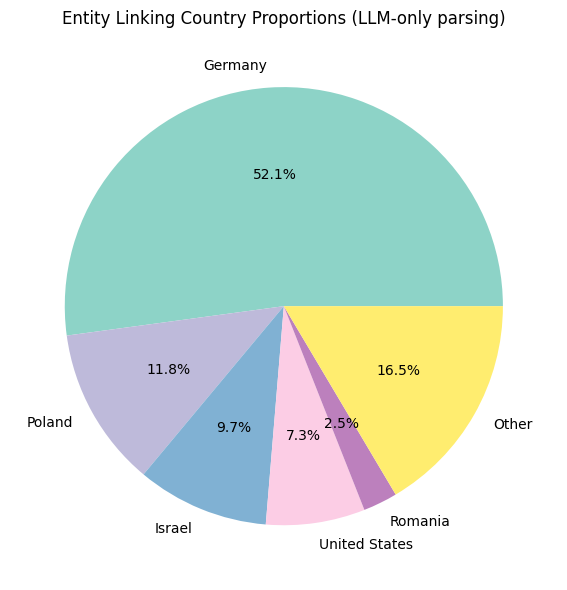

In [23]:
country_occurrences = utils.country_occurrences(outcomes)
utils.plot_country_pie(country_occurrences, title="Entity Linking Country Proportions (LLM-only parsing)", top_n=5)
utils.display_country_occurrences(country_occurrences)

In [24]:
unmatched_entities = utils.build_unmatched_entities_df(bzkopen_merged, outcomes)
unmatched_entities

,address_id,bzk_field_name,full_address,search_status,disambiguation_status
0,159,ApplicantBirthPlace,Scheumargorosch/Rum.,GEO_DB_NO_CANDIDATES,NO_CANDIDATES
1,322,VictimCurrentAddress,"Beer Jakow. Beth Olim A, 14",GEO_DB_NO_CANDIDATES,NO_CANDIDATES
2,478,ApplicantBirthPlace,"Dacha Wojczynska, West Ukraine",GEO_DB_NO_CANDIDATES,NO_CANDIDATES
3,603,ApplicantCurrentAddress,Im Moore 35,GEO_DB_NO_CANDIDATES,NO_CANDIDATES
4,825,VictimBirthPlace,Madiorban-Hedersch/Ung.,GEO_DB_NO_CANDIDATES,NO_CANDIDATES
5,926,VictimBirthPlace,Neybator,GEO_DB_NO_CANDIDATES,NO_CANDIDATES
6,946,ApplicantCurrentAddress,Tel Aviv Schech Schapira Re<UNK> Schiwat Zion 18,GEO_DB_NO_CANDIDATES,NO_CANDIDATES
7,954,VictimCurrentAddress,London N.W. 6 70 Compayne Gardens,GEO_DB_NO_CANDIDATES,NO_CANDIDATES
8,1038,ApplicantBirthPlace,St. Ryj Ukrainien,GEO_DB_NO_CANDIDATES,NO_CANDIDATES


In [25]:
ambiguous_addresses = utils.build_ambiguous_addresses_df(bzkopen_merged, outcomes)
ambiguous_addresses

""


In [26]:
utils.print_ambiguous_example(ambiguous_addresses)

No ambiguous addresses found.
